In [ ]:
#텍스트 분석을 위한 라이브러리 설치 (한국어 : Konlpy / 일본어 : janome)
#テキスト分析のためのライブラリのインストール（韓国語: Konlpy / 日本語: janome）

!pip install Konlpy
!pip install janome

In [ ]:
#한국어 문장을 text에 입력하고 결과 확인
#

from konlpy.tag import Okt

# Okt 형태소 분석기 불러오기
# Okt形態素解析器を呼び出す

okt = Okt()

# 분석할 텍스트
# 分析するテキスト
text = "안녕하세요. 저는 정보 교사입니다."

# 품사 분석
# 品詞分析
pos_result = okt.pos(text)

# 분석 결과 출력
# 分析結果を出力
[print(f'{word}: {pos}') for word, pos in pos_result]
print(pos_result)


In [ ]:
from janome.tokenizer import Tokenizer

# Tokenizer 생성
tokenizer = Tokenizer()

# 분석할 일본어 텍스트
text = "私は学生です。今日はいい天気ですね。"

# 형태소 분석 및 품사 태깅
for token in tokenizer.tokenize(text):
    print(f"Word: {token.surface}, Part of Speech: {token.part_of_speech}")


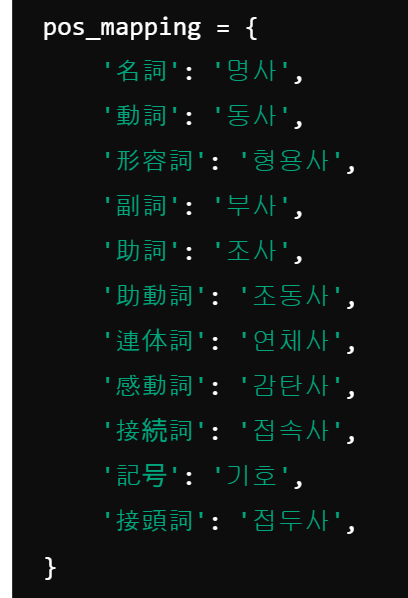

In [ ]:
#text에 들어있는 문장을 품사별로 발생 빈도를 계산하여 CSV 파일로 출력(한국어)
#textに含まれる文章の品詞ごとの出現頻度を計算し、CSVファイルに出力する（韓国語)

import pandas as pd
from konlpy.tag import Okt

# Okt 형태소 분석기 초기화
# Okt形態素解析器の初期化
okt = Okt()

# 분석할 텍스트
# 分析対象テキスト
text = ""

# 품사 분석
# 品詞分析
pos_result = okt.pos(text)

# 빈도 수 계산을 위한 딕셔너리 초기화
# 頻度数計算のためのディクショナリ初期化
freq_dict = {}

# 빈도 수 계산
# 頻度数計算
for word, pos in pos_result:
    key = (word, pos)
    if key in freq_dict:
        freq_dict[key] += 1
    else:
        freq_dict[key] = 1

# 데이터프레임 생성 (컬럼 순서: 단어, 빈도, 품사)
# データフレーム生成（カラム順：単語、頻度、品詞）
df = pd.DataFrame([(word, freq, pos) for (word, pos), freq in freq_dict.items()], columns=['단어', '빈도', '품사'])

# 결과 출력
# 結果出力
print(df)

# CSV 파일로 저장
# CSVファイルに保存
df.to_csv('frequency_analysis(KR).csv', encoding='utf-8-sig', index=False)


In [ ]:
#text에 들어있는 문장을 품사별로 발생 빈도를 계산하여 CSV 파일로 출력(일본어)
#textに含まれる文章の品詞ごとの出現頻度を計算し、CSVファイルに出力する（日本語）

import pandas as pd
from janome.tokenizer import Tokenizer

# Tokenizer 생성
# Tokenizerの作成
tokenizer = Tokenizer()

# 분석할 일본어 텍스트
# 分析対象の日本語テキスト
text = ""

# 형태소 분석 및 품사 태깅
# 形態素解析と品詞タグ付け
token_list = tokenizer.tokenize(text)

# 빈도 수 계산을 위한 딕셔너리 초기화
# 頻度数計算のためのディクショナリ初期化
freq_dict = {}

# 빈도 수 계산
# 頻度数計算
for token in token_list:
    word = token.surface
    pos = token.part_of_speech.split(',')[0]  # 첫 번째 품사 정보만 사용
    key = (word, pos)
    if key in freq_dict:
        freq_dict[key] += 1
    else:
        freq_dict[key] = 1

# 데이터프레임 생성 (컬럼 순서: 단어, 빈도, 품사)
# データフレーム生成（カラム順：単語、頻度、品詞）
df = pd.DataFrame([(word, freq, pos) for (word, pos), freq in freq_dict.items()], columns=['単語', '頻度', '品詞'])

# 결과 출력
# 結果出力
print(df)

# CSV 파일로 저장
# CSVファイルに保存
df.to_csv('frequency_analysis(JP).csv', encoding='utf-8-sig', index=False)


In [ ]:
#text 메모장 파일을 활용한 품사 빈도 분석 파일 생성 (한국어)
#textメモ帳ファイルを利用した品詞頻度分析ファイルの生成（韓国語）

import io
import pandas as pd
from konlpy.tag import Okt
from ipywidgets import FileUpload, Button, Output
from IPython.display import display

# 형태소 분석기 초기화
# 形態素解析器の初期化
okt = Okt()

# 파일 업로드 위젯 생성
# ファイルアップロードウィジェットの生成
upload = FileUpload(accept='.txt', multiple=False)
upload_button = Button(description='분석 시작')
output_area = Output()

def process_text(b):
    # 업로드된 파일 읽기
    # アップロードされたファイルを読む
    uploaded_filename = next(iter(upload.value))
    content = upload.value[uploaded_filename]['content']
    text = io.StringIO(content.decode('utf-8')).read()

    # 형태소 분석 및 빈도 계산
    # 形態素解析と頻度計算
    pos_result = okt.pos(text)
    freq_dict = {}
    for word, pos in pos_result:
        key = (word, pos)
        if key in freq_dict:
            freq_dict[key] += 1
        else:
            freq_dict[key] = 1

    # 데이터프레임 생성 (컬럼 순서: 빈도, 단어, 품사)
    # データフレーム生成（カラム順：頻度、単語、品詞）
    df = pd.DataFrame([(word, freq, pos) for (word, pos), freq in freq_dict.items()], columns=['단어', '빈도', '품사'])
    df.sort_values(by='빈도', ascending=False, inplace=True)

    # 결과 출력 및 CSV 저장
    # 結果出力とCSV保存
    with output_area:
        output_area.clear_output()
        print(df.head())
        df.to_csv('frequency_analysis(kor_file).csv', encoding='utf-8-sig', index=False)
        print('CSV 파일이 저장되었습니다.')

# 버튼 클릭 이벤트 처리
# ボタンクリックイベント処理
upload_button.on_click(process_text)

# 위젯 표시
# ウィジェット表示
display(upload, upload_button, output_area)


In [ ]:
#text 메모장 파일을 활용한 품사 빈도 분석 파일 생성 (일본어)
#「text メモ帳ファイルを利用した品詞別頻度分析ファイルの生成（日本語）」

import io
import pandas as pd
from janome.tokenizer import Tokenizer
from ipywidgets import FileUpload, Button, Output
from IPython.display import display

# 형태소 분석기 생성
# 形態素解析器の生成
tokenizer = Tokenizer()

# 파일 업로드 위젯 생성
# ファイルアップロードウィジェットの生成
upload = FileUpload(accept='.txt', multiple=False)
upload_button = Button(description='分析開始')
output_area = Output()

# 품사 매핑 딕셔너리
# 品詞マッピングディクショナリ
pos_mapping = {
    '名詞': '명사',
    '動詞': '동사',
    '形容詞': '형용사',
    '副詞': '부사',
    '助詞': '조사',
    '助動詞': '조동사',
    '連体詞': '연체사',
    '感動詞': '감탄사',
    '接続詞': '접속사',
    '記号': '기호',
    '接頭詞': '접두사',
}

def process_text(b):
    # 업로드된 파일 읽기
    # アップロードされたファイルの読み込み
    uploaded_filename = next(iter(upload.value))
    content = upload.value[uploaded_filename]['content']
    text = io.StringIO(content.decode('utf-8')).read()

    # 형태소 분석 및 빈도 계산
    # 形態素解析と頻度計算
    tokens = tokenizer.tokenize(text)
    freq_dict = {}
    for token in tokens:
        word = token.surface
        pos = token.part_of_speech.split(',')[0]  # 첫 번째 품사 정보만 사용
        key = (word, pos)
        if key in freq_dict:
            freq_dict[key] += 1
        else:
            freq_dict[key] = 1

    # 데이터프레임 생성 (컬럼 이름: 単語, 頻度, 品詞, pos)
    # データフレーム生成（カラム名：単語、頻度、品詞、pos）
    df = pd.DataFrame([(word, freq, pos, pos_mapping.get(pos, "기타")) for (word, pos), freq in freq_dict.items()], columns=['単語', '頻度', '品詞', 'pos'])
    df.sort_values(by='頻度', ascending=False, inplace=True)

    # 결과 출력 및 CSV 저장
    # 結果の出力とCSV保存
    with output_area:
        output_area.clear_output()
        print(df.head())
        df.to_csv('japanese_frequency_analysis.csv', encoding='utf-8-sig', index=False)
        print('CSVファイルが保存されました。')

# 버튼 클릭 이벤트 처리
# ボタンクリックイベントの処理
upload_button.on_click(process_text)

# 위젯 표시
# ウィジェットの表示
display(upload, upload_button, output_area)
